Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MSE hata skoru: 34.94174063316996
RMSE : 5.911153917228848
Eğim:  [5.94099838]
R^2: 0.8912243172419237
Kesişim noktası: 23.6559177638527


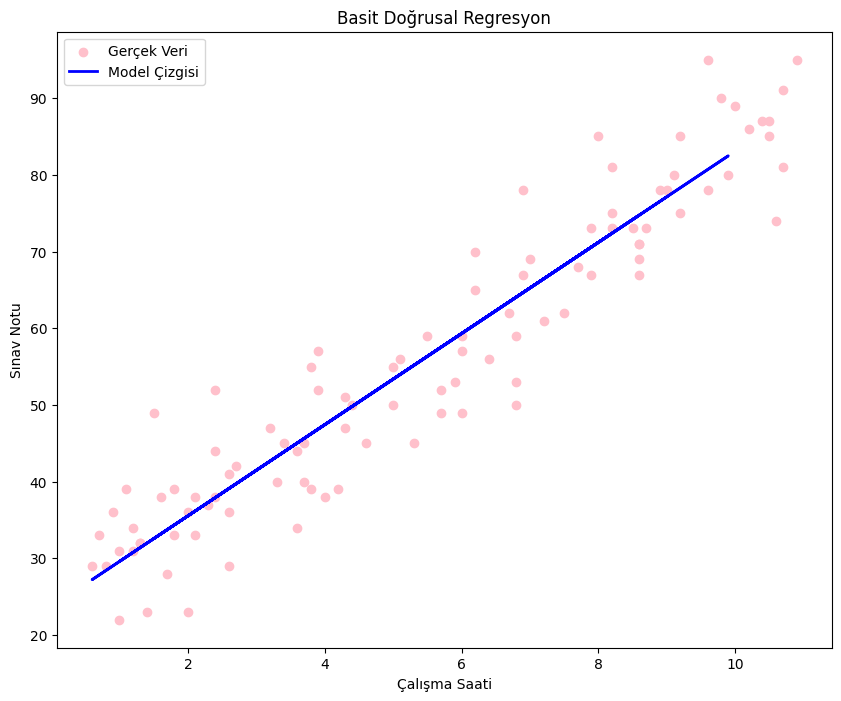

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
ver_yolu="/content/drive/My Drive/Tech İstanbul/ogrenci_calisma_notlari.csv"

import pandas as pd
import matplotlib.pyplot as plt

veri=pd.read_csv(ver_yolu)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

x=veri[["calisma_saati"]]
y=veri["sinav_notu"]
x_egitim,x_test,y_egitim,y_test= train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_egitim, y_egitim)
y_tahmin=model.predict(x_test)
mse=mean_squared_error(y_test,y_tahmin)
print("MSE hata skoru:", mse)
print("RMSE :",mse**(0.5))
print("Eğim: ",model.coef_)

r2 = r2_score(y_test, y_tahmin)
print("R^2:", r2)
print("Kesişim noktası:" , model.intercept_)
plt.figure(figsize=(10,8))
plt.scatter(x,y,color="pink",label="Gerçek Veri")
plt.plot(x_test,y_tahmin,color="blue",linewidth=2,label="Model Çizgisi")
plt.title("Basit Doğrusal Regresyon")
plt.xlabel("Çalışma Saati")
plt.ylabel("Sınav Notu")
plt.legend()
plt.show()